# Отчёт по датасету спроса

У датасета один потребитель — трансформер-прогнозист (`training/forecaster`). Отчёт показывает данные, на которых он обучается, и точный вход, который он видит.

Генерация: `python -m data.generate_demand` → `data/demand/`.
Качество прогноза — в `transformer_report.ipynb`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def _find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "data" / "generate_demand.py").exists():
            return candidate
    raise RuntimeError("project root not found (data/generate_demand.py)")


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from core.config import Weather
from data.generate_demand import DEMAND_DIR, load_demand
from training.forecaster.model import WINDOW, build_features, make_windows

plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

arrays, manifest = load_demand(DEMAND_DIR)
demand = arrays["demand"]
n_series, n_days = demand.shape
split = manifest["split"]

print(f"series: {n_series}  days: {n_days}  master_seed: {manifest['master_seed']}")
print(f"split: {split}")
print(f"dataset_sha256: {manifest['dataset_sha256'][:16]}...")

series: 50  days: 2000  master_seed: 0
split: {'test': [1700, 2000], 'train': [0, 1400], 'val': [1400, 1700]}
dataset_sha256: 83fcec70be6b4395...


## Базовая статистика

In [2]:
event = arrays["event_multiplier"]
noise = demand - arrays["demand_mean"]

pd.DataFrame({
    "value": [
        demand.mean(), demand.std(), demand.min(), demand.max(),
        noise.std(),
        float((event > 1.0).mean()),
        float(event[event > 1.0].mean()),
    ],
}, index=[
    "средний спрос", "std спроса", "min", "max",
    "std шума (demand - demand_mean)",
    "доля event-дней",
    "средний множитель в event-дни",
]).round(3)

,value
средний спрос,0.186
std спроса,0.070
min,0.049
max,0.844
std шума (demand - demand_mean),0.020
доля event-дней,0.038
средний множитель в event-дни,2.005


## Пример ряда и сплиты

`demand_mean` — ожидаемый спрос генератора (все множители, без шума): нижняя граница ошибки, которую не пробьёт ни один прогнозист (oracle floor).

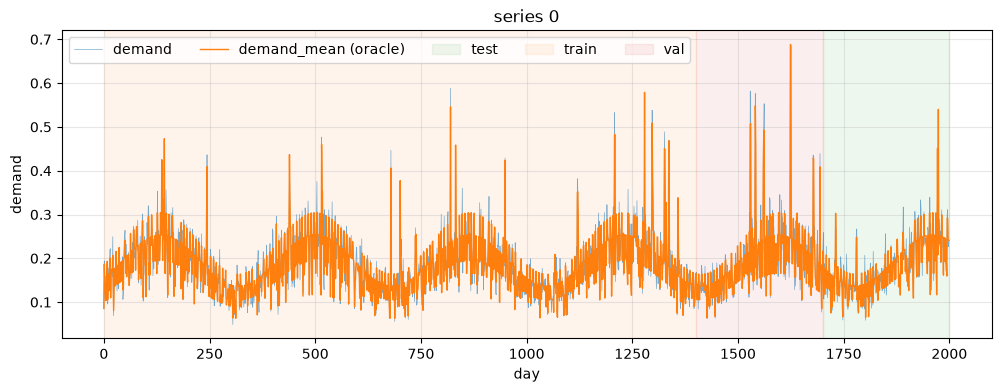

In [3]:
s = 0
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(demand[s], lw=0.5, alpha=0.6, label="demand")
ax.plot(arrays["demand_mean"][s], lw=1.0, label="demand_mean (oracle)")
for name, color in zip(split, ["tab:green", "tab:orange", "tab:red"]):
    lo, hi = split[name]
    ax.axvspan(lo, hi, alpha=0.08, color=color, label=name)
ax.set(xlabel="day", ylabel="demand", title=f"series {s}")
ax.legend(ncols=5)
plt.show()

## Предсказуемый сигнал

Четыре драйвера, которые трансформер должен извлечь: недельный профиль, годовая сезонность, множитель погоды, event-всплески.

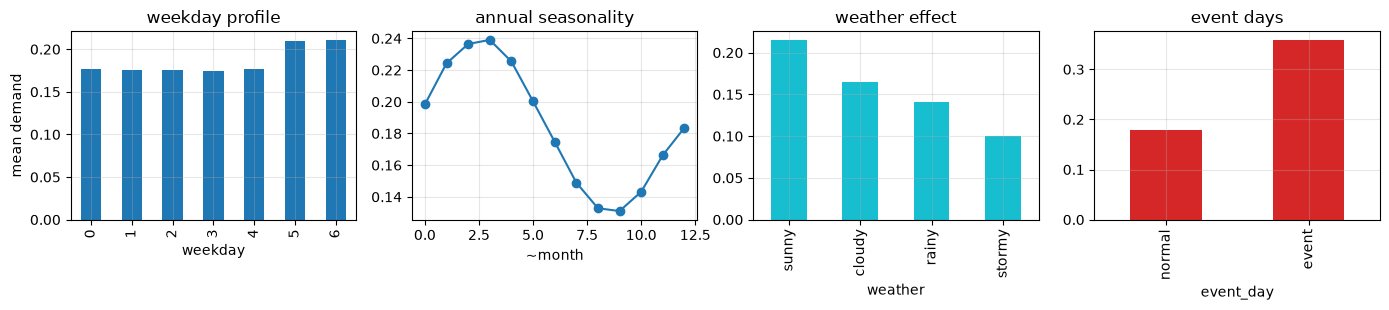

In [4]:
df = pd.DataFrame({
    "demand": demand.reshape(-1),
    "weekday": arrays["weekday"].reshape(-1),
    "day_of_year": arrays["day_of_year"].reshape(-1),
    "weather": arrays["weather"].reshape(-1),
    "event_day": (event > 1.0).reshape(-1),
})
weather_names = dict(enumerate(w.value for w in Weather))

fig, axes = plt.subplots(1, 4, figsize=(14, 3.2))
df.groupby("weekday")["demand"].mean().plot.bar(ax=axes[0], color="tab:blue")
axes[0].set(title="weekday profile", ylabel="mean demand")
df.groupby(df["day_of_year"] // 30)["demand"].mean().plot(ax=axes[1], marker="o")
axes[1].set(title="annual seasonality", xlabel="~month")
df.groupby("weather")["demand"].mean().rename(index=weather_names).plot.bar(
    ax=axes[2], color="tab:cyan"
)
axes[2].set(title="weather effect")
df.groupby("event_day")["demand"].mean().rename(
    index={False: "normal", True: "event"}
).plot.bar(ax=axes[3], color="tab:red")
axes[3].set(title="event days")
fig.tight_layout()
plt.show()

## Вход трансформера

`build_features` разворачивает массивы в поканальные признаки на день; `make_windows` режет скользящие окна: `WINDOW` дней истории плюс токен целевого дня (известные ковариаты дня *t*; каналы спроса и события занулены — утечки нет).

In [5]:
features = build_features(arrays)
channel_names = [
    "demand_norm", "event_mult-1",
    "sin_year", "cos_year", "sin_week", "cos_week",
    *(f"weather_{w.value}" for w in Weather),
]
print(f"features: {features.shape}  (series, days, channels)")
display(pd.DataFrame(features[0, :5], columns=channel_names).round(3))

for name in split:
    x, y = make_windows(features, *split[name])
    print(f"{name:>5}: X {x.shape}  y {y.shape}")
print(f"sequence = {WINDOW} history days + 1 target-day token")

features: (50, 2000, 10)  (series, days, channels)


,demand_norm,event_mult-1,sin_year,cos_year,sin_week,cos_week,weather_sunny,weather_cloudy,weather_rainy,weather_stormy
0,0.565,0.0,-0.687,0.727,-0.975,-0.223,0.0,0.0,0.0,1.0
1,1.293,0.0,-0.674,0.738,-0.782,0.623,1.0,0.0,0.0,0.0
2,0.963,0.0,-0.662,0.750,0.000,1.000,1.0,0.0,0.0,0.0
3,0.731,0.0,-0.649,0.761,0.782,0.623,0.0,1.0,0.0,0.0
4,0.688,0.0,-0.635,0.772,0.975,-0.223,0.0,1.0,0.0,0.0


 test: X (15000, 29, 10)  y (15000,)
train: X (68600, 29, 10)  y (68600,)
  val: X (15000, 29, 10)  y (15000,)
sequence = 28 history days + 1 target-day token
